# Telecom Customer Churn Prediction

In [1]:
#Importing Required Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv("/kaggle/input/datasets/suraj520/telecom-churn-dataset/telecom_churn.csv")

# Data Understanding & Insights

In [3]:
df.head() #displays starting 5 rows 

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [4]:
# After Understanding the Dataset got to see that 
# This is a Binary Classification problem:
# 0 → Customer will not churn
# 1 → Customer will churn

In [5]:
df.tail()#displays Last 5 rows in the data

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
243548,243549,Airtel,F,28,Mizoram,Kolkata,110295,2023-05-03,3,130580,28,9,4102,0
243549,243550,Reliance Jio,F,52,Assam,Kolkata,713481,2023-05-03,0,82393,80,45,7521,0
243550,243551,Reliance Jio,M,59,Tripura,Kolkata,520218,2023-05-03,4,51298,26,4,6547,0
243551,243552,BSNL,M,49,Madhya Pradesh,Kolkata,387744,2023-05-03,2,83981,80,15,1125,0
243552,243553,BSNL,F,37,Telangana,Hyderabad,139086,2023-05-04,0,144297,61,7,3384,0


In [6]:
df.shape #displays total numbers or rows and columns presentin the dataset

(243553, 14)

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB
None


In [8]:
# .info will tell the basic info. about total columns and rows and their datatypes , will also tell about null values 

In [9]:
print(df.isnull().sum())

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64


In [10]:
# .null will tell us is there any null value exist or not...

In [11]:
print(df.duplicated().sum())

0


In [12]:
# .duplicated will help us to find that is there any duplicates in dataset....
# T/F then sum will change it to 0 and 1

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,243553.0,121777.000000,70307.839393,1.0,60889.0,121777.0,182665.0,243553.0
age,243553.0,46.077609,16.444029,18.0,32.0,46.0,60.0,74.0
pincode,243553.0,549501.270541,259808.860574,100006.0,324586.0,548112.0,774994.0,999987.0
num_dependents,243553.0,1.997500,1.414941,0.0,1.0,2.0,3.0,4.0
estimated_salary,243553.0,85021.137839,37508.963233,20000.0,52585.0,84990.0,117488.0,149999.0
calls_made,243553.0,49.010548,29.453556,-10.0,24.0,49.0,74.0,108.0
sms_sent,243553.0,23.945404,14.733575,-5.0,11.0,24.0,36.0,53.0
data_used,243553.0,4993.186025,2942.019547,-987.0,2490.0,4987.0,7493.0,10991.0
churn,243553.0,0.200478,0.400359,0.0,0.0,0.0,0.0,1.0


In [14]:
#Descirbe helps us to understand statstical summary of Data

In [15]:
print(df['churn'].value_counts())

print("\nChurn Percentage:")
print(df['churn'].value_counts(normalize=True) * 100)

churn
0    194726
1     48827
Name: count, dtype: int64

Churn Percentage:
churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64


In [16]:
# checking the data is balanced or not but can see 
# Target Distribution is aorund 80% customers are not churned 20% customers are churned
# So Dataset is imbalanced/ bias 

In [17]:
# Identify numerical and categorical features
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Remove target variable from numerical features (if present)
if "churn" in num_cols:
    num_cols.remove("churn")

# Display feature lists
print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
['customer_id', 'age', 'pincode', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used']

Categorical Features:
['telecom_partner', 'gender', 'state', 'city', 'date_of_registration']


In [18]:
# Insight:
# Separating numerical and categorical features helps apply appropriate preprocessing,
# visualization, and feature engineering techniques. It also ensures the target
# variable is excluded from exploratory analysis and model preprocessing steps.

# Checking Data Quality 

In [19]:
(cols := ['calls_made', 'sms_sent', 'data_used'])

for col in cols:
    print(col, (df[col] < 0).sum())

calls_made 6713
sms_sent 7375
data_used 6050


In [20]:
# As seen earlier few columns were having -ve values present inside 'calls_made', 'sms_sent', 'data_used' so made them positive 

In [21]:
for col in ['calls_made', 'sms_sent', 'data_used']:
    df[col] = df[col].abs()

In [22]:
(cols := ['calls_made', 'sms_sent', 'data_used'])

for col in cols:
    print(col, (df[col] < 0).sum())

calls_made 0
sms_sent 0
data_used 0


# Univariate Analysis

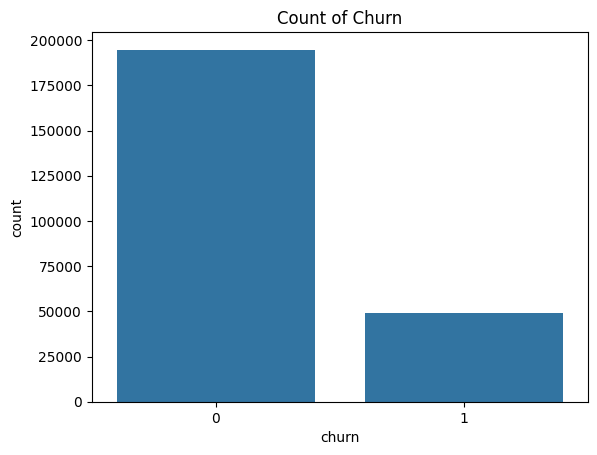

In [23]:
sns.countplot(x="churn", data=df)
plt.title("Count of Churn")
plt.show()

In [24]:
print(df['churn'].value_counts())

print("\nChurn Percentage:")
print(df['churn'].value_counts(normalize=True) * 100)

churn
0    194726
1     48827
Name: count, dtype: int64

Churn Percentage:
churn
0    79.952208
1    20.047792
Name: proportion, dtype: float64


In [25]:
# checking outliers for numerical columns 

age


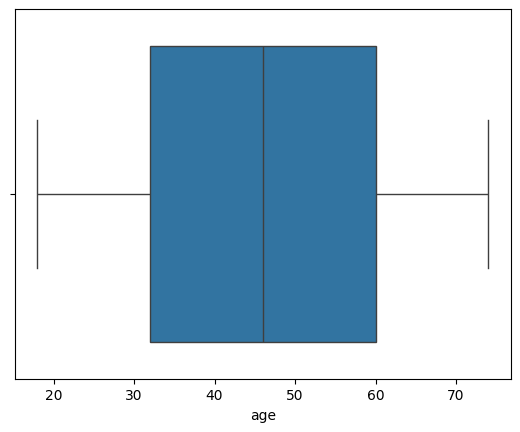

estimated_salary


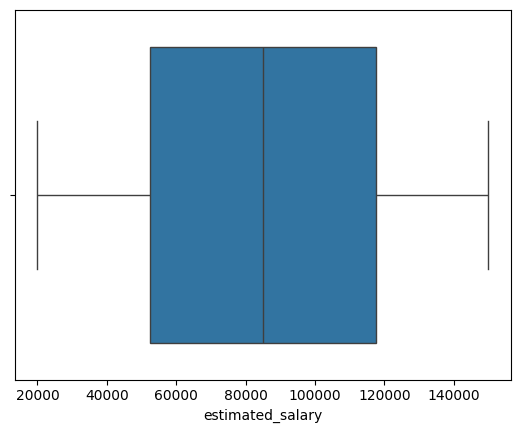

calls_made


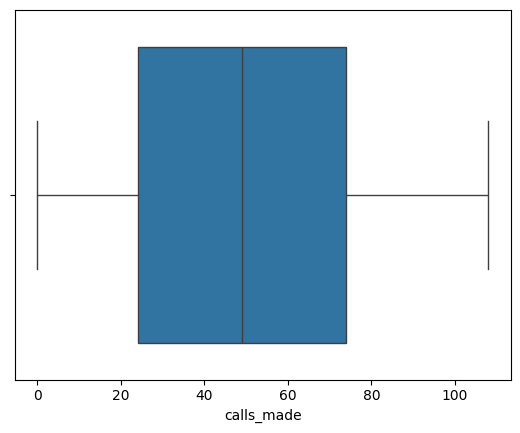

sms_sent


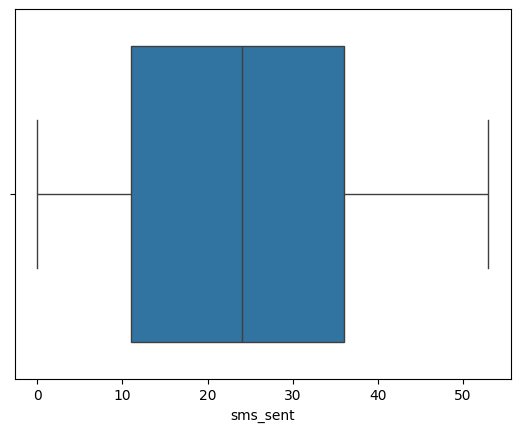

data_used


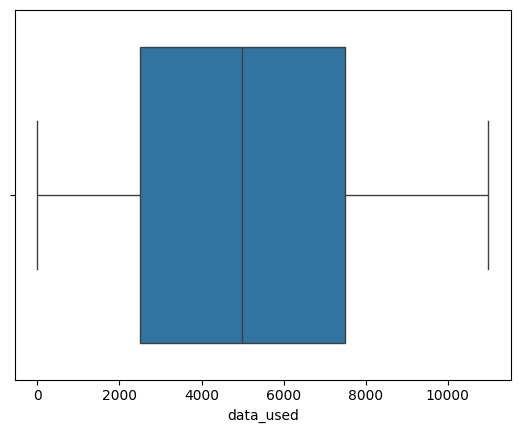

num_dependents


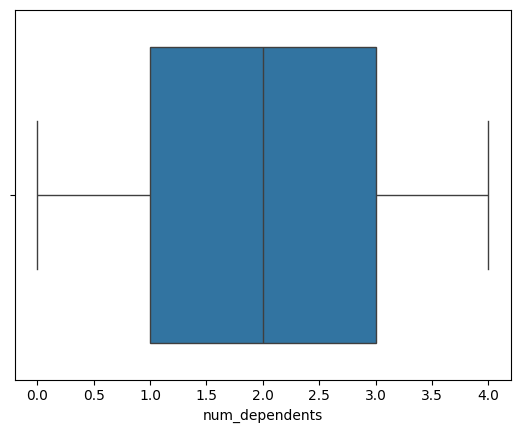

In [26]:
num_cols = ['age', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'num_dependents']

for col in num_cols:
    print(col)
    sns.boxplot(x=df[col])
    plt.show()

In [27]:
# Boxplot Analysis:

# Age:
# Age values are consistently distributed across customers.
# The median age is around 47 years.
# No notable outliers are observed.

# Estimated Salary:
# Salaries show a broad distribution, reflecting varying income levels.
# The median salary is approximately ₹85,000.
# No significant salary outliers are present.

# Calls Made:
# Most customers have a moderate call frequency.
# The median is close to 55 calls.
# No abnormal call patterns are detected.

# SMS Sent:
# SMS activity is evenly distributed among customers.
# The median is approximately 25 messages.
# No extreme observations are visible.

# Data Used:
# Data consumption shows moderate variability across customers.
# The median usage is around 5,500 MB.
# No unusually high or low values are identified.

# Number of Dependents:
# The number of dependents ranges from 0 to 4.
# The median value is 2 dependents.
# No outliers are detected.

# Overall Insights:
# Boxplots indicate that all numerical features are free from significant outliers.
# The distributions exhibit a reasonable spread with balanced interquartile ranges (IQRs).
# Median values are well positioned within the boxes, indicating stable distributions.
# As no influential outliers are present, additional outlier treatment is unnecessary.
# The numerical features are well-suited for further analysis and model development.

In [28]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "Outliers:", outliers.shape[0])

age Outliers: 0
estimated_salary Outliers: 0
calls_made Outliers: 0
sms_sent Outliers: 0
data_used Outliers: 0
num_dependents Outliers: 0


In [29]:
# IQR-based outlier detection confirms the boxplot analysis, with no outliers found in any numerical feature.
# Therefore, outlier treatment is not required before model training.

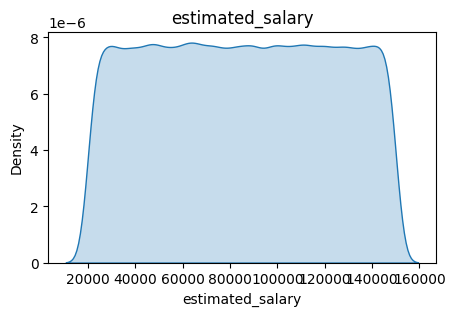

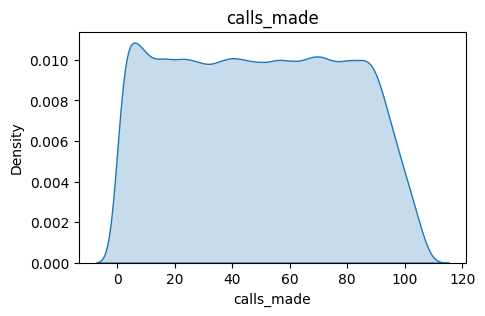

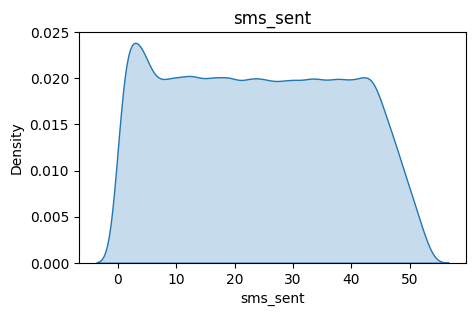

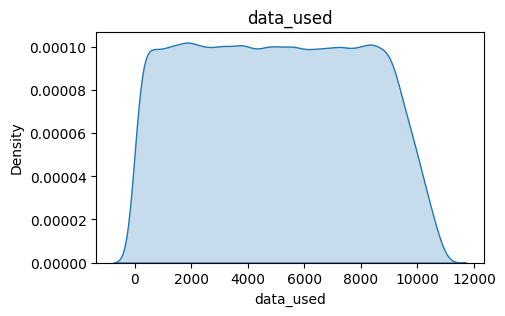

In [30]:
cols = ['estimated_salary', 'calls_made', 'sms_sent', 'data_used']

for col in cols:
    plt.figure(figsize=(5,3))
    sns.kdeplot(df[col], fill=True)
    plt.title(col)
    plt.show()

In [31]:
# KDE Plot Analysis:

# Estimated Salary:
# Salary values are broadly and evenly distributed across the observed range.
# No noticeable skewness or concentration of values is present.

# Calls Made:
# Call frequency shows a balanced distribution with no dominant peak.
# Customer calling behavior appears relatively consistent.

# SMS Sent:
# SMS usage is evenly spread across customers.
# No irregular distribution patterns are observed.

# Data Used:
# Data usage is distributed smoothly throughout the range.
# No major skewness or clustering is evident.

# Overall Insights:
# KDE plots indicate that the numerical features have stable and well-distributed value ranges.
# No significant skewness, multimodal patterns, or abnormal distributions are observed.
# The features appear suitable for model training without requiring substantial distribution-based preprocessing.

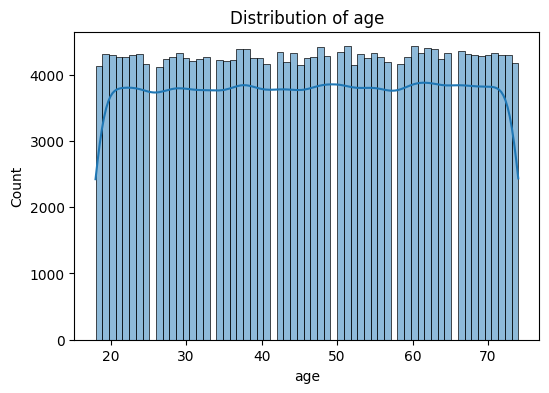

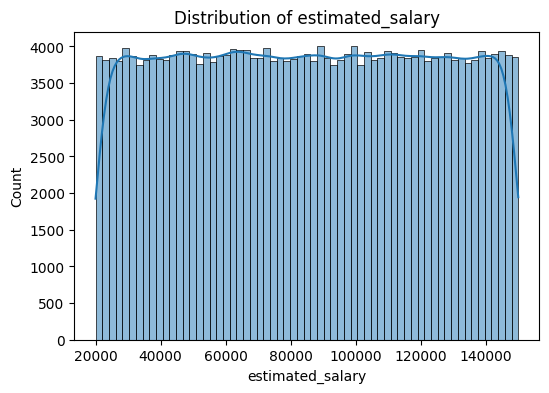

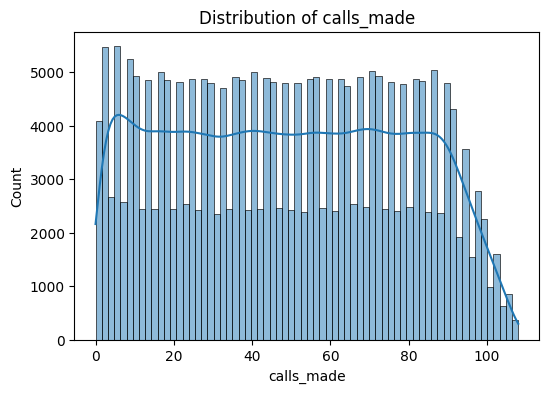

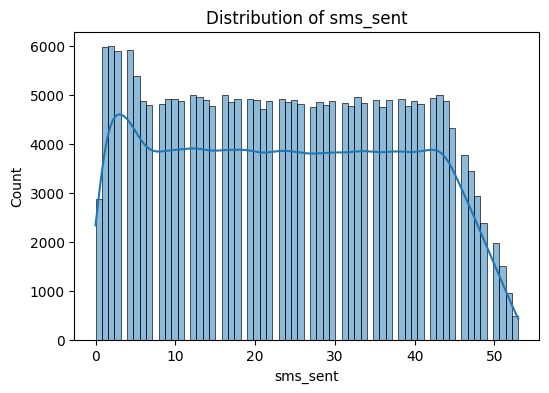

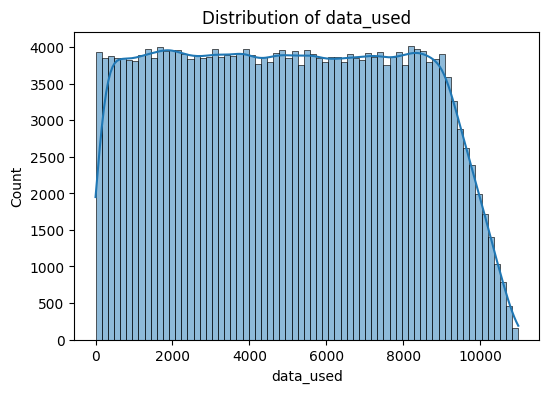

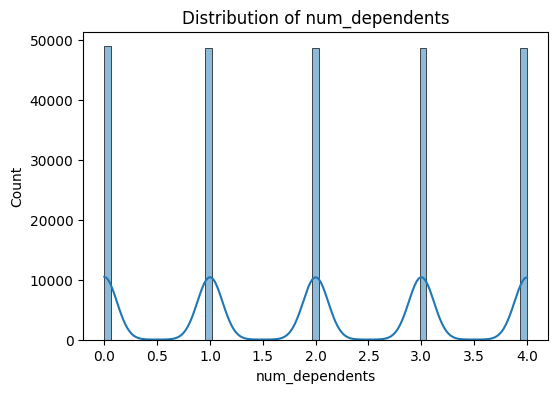

In [32]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [33]:
# Distribution of Age:
# Customers are evenly represented across different age groups.
# The distribution appears balanced with no noticeable skewness.
# Most age ranges contribute similarly to the dataset.
# No abnormal patterns are observed.

# Distribution of Estimated Salary:
# Estimated salaries are spread across a broad income range.
# The distribution remains fairly uniform without a dominant salary group.
# Income levels are well represented throughout the dataset.
# No significant irregularities are visible.

# Distribution of Calls Made:
# Call frequency is distributed consistently across customers.
# Moderate call counts are slightly more common than the extremes.
# The feature shows a balanced distribution with minimal skewness.
# No unusual calling behavior is observed.

# Distribution of SMS Sent:
# SMS activity is evenly distributed among customers.
# Medium SMS usage occurs more frequently than very low or very high usage.
# The distribution remains stable without noticeable skewness.
# No abnormal patterns are detected.

# Distribution of Data Used:
# Data usage spans a wide range of values across customers.
# Most observations fall within moderate usage levels.
# The distribution is relatively balanced with no prominent skewness.
# No unusual concentration of values is observed.

# Distribution of Number of Dependents:
# The feature contains a limited set of discrete values ranging from 0 to 4.
# Customers are reasonably distributed across all dependent categories.
# No single category dominates the dataset.
# The distribution appears balanced.

# Overall Insights:
# The numerical features exhibit stable and well-balanced distributions.
# No substantial skewness or unusual distribution patterns are evident.
# The observed distributions indicate good data quality for further analysis.
# Since the features are already well distributed, no major distribution-based transformations are required before model training.

In [34]:
# Calculate the number and percentage of customers with an estimated salary
# between ₹20,000 and ₹40,000 to understand the distribution within this income range.

count = df[
    (df["estimated_salary"] >= 20000) &
    (df["estimated_salary"] <= 40000)
].shape[0]

percentage = count / len(df) * 100

print(count)
print(f"{percentage:.2f}%")

37308
15.32%


In [35]:
# Approximately 15.32% of customers have an estimated salary between ₹20,000 and ₹40,000.
# This indicates that this income group represents a moderate portion of the customer base,
# while the remaining customers are distributed across higher salary ranges.

In [36]:
# Count the number of customers who made between 20 and 40 calls
# to understand the proportion of users with moderate call activity.

count = df[
    (df["calls_made"] >= 20) &
    (df["calls_made"] <= 40)
].shape[0]

print(count)

50970


In [37]:
# A total of 50,970 customers made between 20 and 40 calls.
# This suggests that a considerable portion of customers exhibit moderate calling behavior,
# indicating this range represents a common usage pattern in the dataset.

In [38]:
# Group estimated salaries into predefined salary ranges
# to understand how customers are distributed across income levels.
pd.cut(
    df["estimated_salary"],
    bins=[20000, 40000, 60000, 80000, 100000, 120000, 150000]
).value_counts().sort_index()

estimated_salary
(20000, 40000]      37307
(40000, 60000]      37397
(60000, 80000]      37731
(80000, 100000]     37426
(100000, 120000]    37600
(120000, 150000]    56091
Name: count, dtype: int64

In [39]:
# Customers are distributed fairly evenly across most salary ranges,
# with each interval containing approximately 37,000 customers.
# The ₹1,20,000–₹1,50,000 range has the highest number of customers,
# indicating a relatively larger population in the upper income segment.

In [40]:
skew_df = pd.DataFrame({
    "Feature": num_cols,
    "Skewness": [df[col].skew() for col in num_cols]
})
skew_df.sort_values(
    "Skewness",
    ascending=False
)

,Feature,Skewness
3,sms_sent,0.056302
2,calls_made,0.039306
4,data_used,0.036654
5,num_dependents,0.001801
1,estimated_salary,0.000973
0,age,-0.007563


In [41]:
# Skewness Analysis:
# The skewness values for all numerical features are very close to zero, indicating well-balanced distributions.
# None of the features show meaningful positive or negative skewness.
# Although SMS Sent has the highest positive skewness (0.0053) and Age has the highest negative skewness (-0.0076),
# both values are negligible and have no practical impact on the data distribution.
# Since the features are already approximately symmetric, skewness correction techniques
# (such as log, square root, or Box-Cox transformations) are not required.
# Overall, the numerical features are well-distributed and ready for model development without additional transformation.

In [42]:
# Categorical feature columns
cat_cols = [
    "gender",
    "telecom_partner",
    "state",
    "city",
]

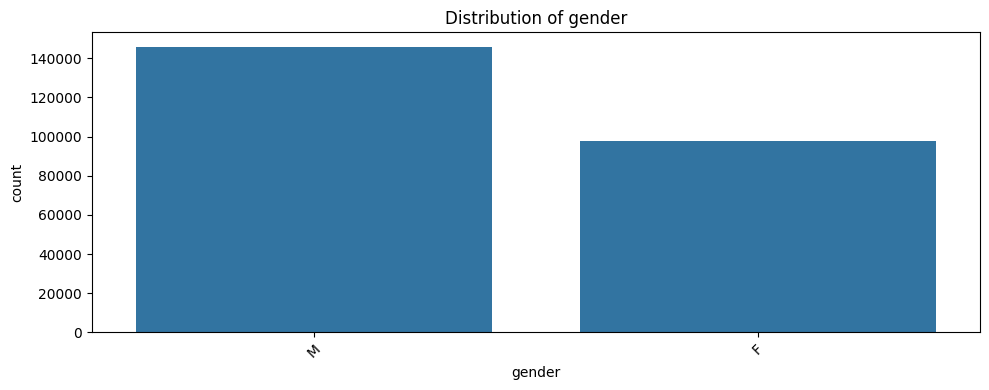

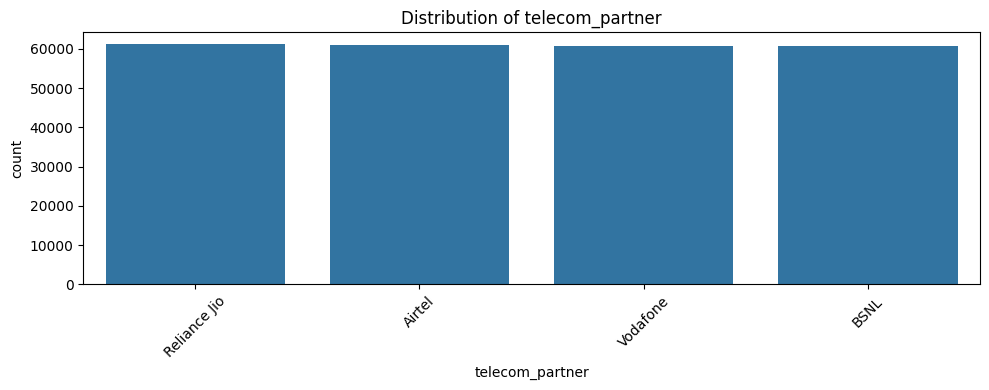

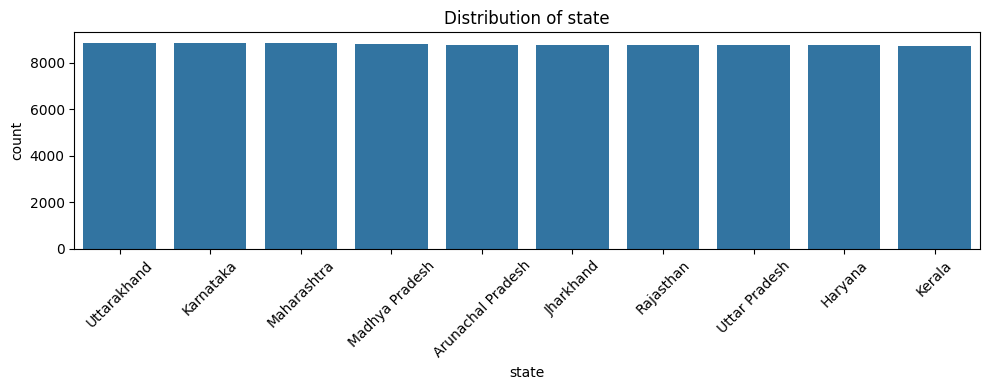

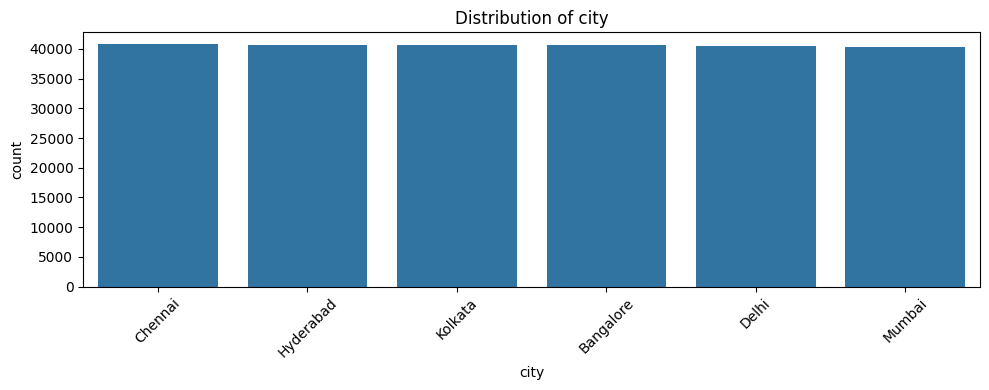

In [43]:
# Visualize the distribution of the top 10 categories for each categorical feature
for col in cat_cols:
    plt.figure(figsize=(10, 4))

    top_categories = df[col].value_counts().index[:10]

    sns.countplot(
        data=df,
        x=col,
        order=top_categories
    )

    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [44]:
# Gender:
# Male customers slightly outnumber female customers.
# Although a minor imbalance exists, both groups are sufficiently represented.
# The distribution is unlikely to introduce significant gender-related bias.

# Telecom Partner:
# Customer records are distributed fairly evenly across all telecom partners.
# No single provider accounts for a disproportionately large share of the dataset.
# This balanced representation supports unbiased model learning.

# State:
# Customers are well distributed across the different states.
# Each state contributes a comparable number of observations.
# No noticeable regional imbalance is observed.

# City:
# Customer representation remains consistent across the listed cities.
# Most cities contribute a similar volume of records.
# The dataset provides broad geographic coverage.

# Overall Insights:
# The categorical features exhibit balanced distributions across most categories.
# A slight dominance of male customers is observed, while the remaining features show minimal variation.
# Overall, the balanced categorical representation reduces the risk of category-specific bias during model training.

In [45]:
# Analyze the cardinality of categorical features
cardinality_df = pd.DataFrame({
    "Feature": cat_cols,
    "Unique Categories": [df[col].unique().size for col in cat_cols],
    "Unique Values": [df[col].nunique() for col in cat_cols]
})
cardinality_df

,Feature,Unique Categories,Unique Values
0,gender,2,2
1,telecom_partner,4,4
2,state,28,28
3,city,6,6


In [46]:
# Insight:
# The categorical features have low to moderate cardinality, making them suitable for encoding.
# Gender, Telecom Partner, and City contain relatively few unique categories,
# while State has the highest number of unique values (28), which is still manageable
# for common categorical encoding techniques.

In [47]:
# Create age groups for demographic analysis
age_bins = [18, 25, 35, 45, 55, 65]
age_labels = ["18–25", "26–35", "36–45", "46–55", "56–65"]

df["age_group"] = pd.cut(
    x=df["age"],
    bins=age_bins,
    labels=age_labels
)
df["age_group"].value_counts().sort_index()

age_group
18–25    29898
26–35    42302
36–45    42649
46–55    43005
56–65    42953
Name: count, dtype: int64

In [48]:
# Customers are grouped into meaningful age categories to simplify demographic analysis.
# This enables easier comparison of customer behavior across different age segments
# and helps identify age-related patterns that may influence churn.

In [49]:
# Categorize customers into salary bands using quartiles
salary_labels = ["Low", "Medium", "High", "Very High"]

df["salary_band"] = pd.qcut(
    x=df["estimated_salary"],
    q=4,
    labels=salary_labels
)

# Display the distribution across salary bands
df["salary_band"].value_counts().sort_index()

salary_band
Low          60892
Medium       60885
High         60889
Very High    60887
Name: count, dtype: int64

In [50]:
# Salary Band Analysis:
# Quartile-based segmentation results in a balanced distribution across all salary bands.
# Each category represents approximately one-fourth of the dataset, enabling meaningful comparisons.
# The balanced grouping is beneficial for exploratory analysis and feature engineering.

In [51]:
# Summarize customer count for each city
city_summary = (
    df["city"]
    .value_counts()
    .reset_index()
)

city_summary.columns = ["City", "Customer Count"]
city_summary

,City,Customer Count
0,Chennai,40749
1,Hyderabad,40698
2,Kolkata,40661
3,Bangalore,40603
4,Delhi,40456
5,Mumbai,40386


In [52]:
# City-wise Distribution:
# Customer records are distributed almost evenly across all cities.
# Chennai has the highest count, while Mumbai has the lowest, but the difference is very small.
# This balanced city representation helps reduce location-specific bias during analysis and model training.

In [53]:
# Calculate the percentage distribution of customers across telecom partners
partner_distribution = (
    df["telecom_partner"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

partner_distribution.columns = ["Telecom Partner", "Percentage (%)"]

partner_distribution

,Telecom Partner,Percentage (%)
0,Reliance Jio,25.10
1,Airtel,25.01
2,Vodafone,24.96
3,BSNL,24.93


In [54]:
# Telecom Partner Distribution:
# Customer distribution is nearly identical across all telecom partners.
# Each provider contributes approximately one-fourth of the total customer base.
# The balanced representation minimizes provider-specific bias and supports fair model training.

In [55]:
# Generate descriptive statistics with additional percentile values
salary_summary = (
    df["estimated_salary"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .to_frame(name="Estimated Salary")
)

salary_summary

,Estimated Salary
count,243553.000000
mean,85021.137839
std,37508.963233
min,20000.000000
1%,21295.520000
5%,26563.600000
25%,52585.000000
50%,84990.000000
75%,117488.000000
95%,143530.000000


In [56]:
# Estimated Salary Statistics:
# The average estimated salary is approximately ₹85,000, with a median of nearly the same value,
# indicating a well-balanced salary distribution.
# Salary values range from ₹20,000 to ₹1,50,000, covering a broad income spectrum.
# The percentile values increase gradually, suggesting a consistent spread of salaries across the dataset.
# No abrupt jumps or unusual patterns are observed, indicating the absence of extreme salary concentrations.

In [57]:
# Calculate the coefficient of variation (CV) for numerical features
cv_summary = pd.DataFrame({
    "Feature": num_cols,
    "Mean": [df[col].mean() for col in num_cols],
    "Standard Deviation": [df[col].std() for col in num_cols]
})

cv_summary["Coefficient of Variation"] = (
    cv_summary["Standard Deviation"] / cv_summary["Mean"]
).round(2)

cv_summary

,Feature,Mean,Standard Deviation,Coefficient of Variation
0,age,46.077609,16.444029,0.36
1,estimated_salary,85021.137839,37508.963233,0.44
2,calls_made,49.229695,29.085783,0.59
3,sms_sent,24.086104,14.502418,0.60
4,data_used,5009.523578,2914.113681,0.58
5,num_dependents,1.997500,1.414941,0.71


In [58]:
# Coefficient of Variation (CV) Analysis:
# Age has the lowest relative variability (CV ≈ 0.36), indicating a consistent age distribution.
# Estimated Salary shows moderate variation (CV ≈ 0.44), reflecting differences in customer income.
# Calls Made (CV ≈ 0.60) and Data Used (CV ≈ 0.59) exhibit moderate variability in customer usage patterns.
# SMS Sent (CV ≈ 0.62) and Number of Dependents (CV ≈ 0.71) show comparatively higher variation,
# suggesting greater diversity in communication behavior and household size.

In [59]:
# Calculate the percentage distribution of customers across states
state_distribution = (
    df["state"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)

state_distribution.columns = ["State", "Percentage (%)"]

state_distribution

,State,Percentage (%)
0,Uttarakhand,3.64
1,Karnataka,3.63
2,Maharashtra,3.62
3,Madhya Pradesh,3.62
4,Arunachal Pradesh,3.60
5,Jharkhand,3.59
6,Rajasthan,3.59
7,Uttar Pradesh,3.59
8,Haryana,3.59
9,Kerala,3.58


In [60]:
# State Distribution:
# Customer records are distributed uniformly across all states.
# Each state contributes a similar percentage of the overall dataset,
# indicating balanced regional representation.
# The even distribution minimizes geographical bias and improves the model's ability
# to generalize across different locations.

In [61]:
# Display the customer count for the top cities
top_cities = (
    df["city"]
    .value_counts()
    .reset_index()
)

top_cities.columns = ["City", "Customer Count"]

top_cities.head(10)

,City,Customer Count
0,Chennai,40749
1,Hyderabad,40698
2,Kolkata,40661
3,Bangalore,40603
4,Delhi,40456
5,Mumbai,40386


In [62]:
# Top Cities Analysis:
# Chennai has the highest number of customers, followed closely by Hyderabad and Kolkata.
# The difference in customer count across cities is minimal, indicating a well-balanced distribution.
# No single city dominates the dataset, ensuring good geographical diversity for model training.

# Bivariate Analysis

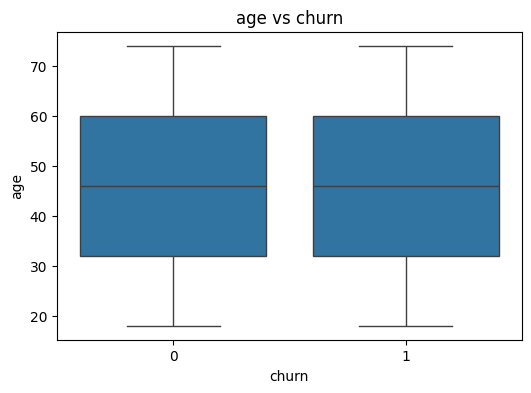

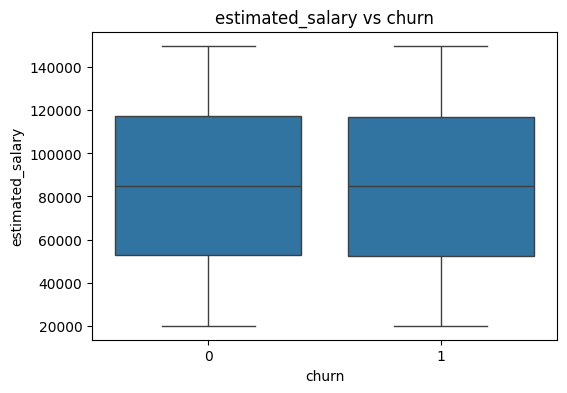

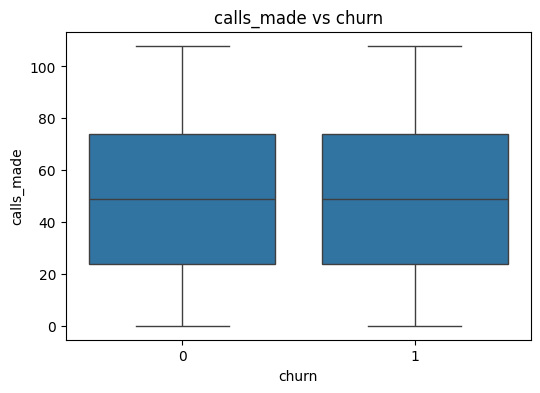

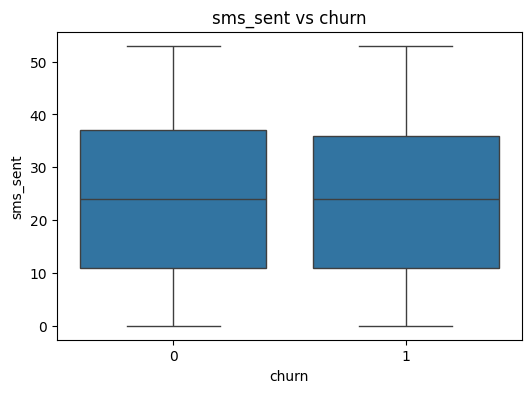

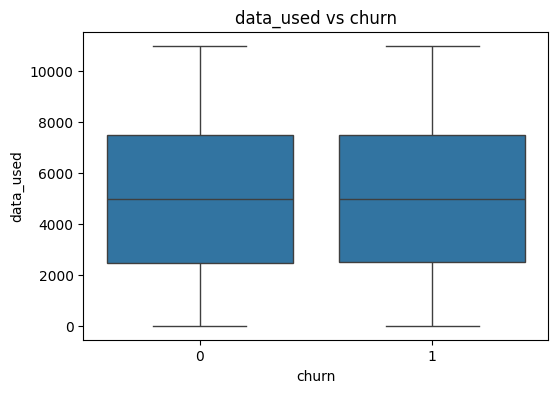

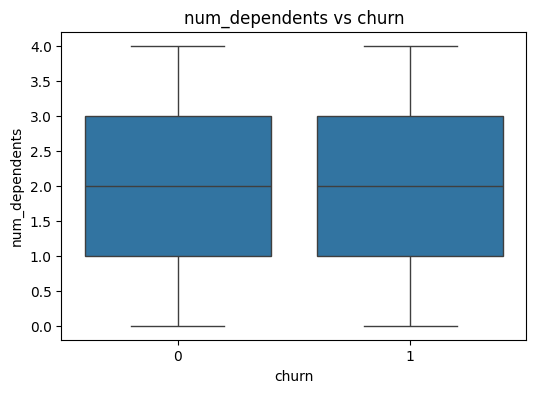

In [63]:
target = 'churn'

for col in num_cols:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[target], y=df[col])
        plt.title(f"{col} vs {target}")
        plt.show()

In [64]:
# Age vs Churn:
# The age distributions for churned and retained customers are largely comparable.
# Similar median values indicate that age alone has a limited influence on churn.
# No clear separation between the two groups is observed.

# Estimated Salary vs Churn:
# Estimated salary follows a similar pattern across both churn categories.
# Median income levels remain nearly unchanged between the groups.
# Salary alone is not a strong differentiating factor for churn.

# Calls Made vs Churn:
# Calling activity shows substantial overlap between churned and non-churned customers.
# Only minor differences are observed in the central tendency.
# Call frequency by itself provides limited information about churn.

# SMS Sent vs Churn:
# SMS usage exhibits a comparable distribution across both customer groups.
# The spread and median values remain highly consistent.
# SMS activity alone does not effectively distinguish churn behavior.

# Data Used vs Churn:
# Internet usage patterns are nearly identical for churned and retained customers.
# Both groups display similar median and distribution ranges.
# Data consumption alone has limited predictive capability.

# Overall Insights:
# The numerical features exhibit significant overlap between churned and retained customers.
# None of the individual variables can independently explain churn behavior.
# This suggests that combining multiple features through feature engineering and machine learning models is essential for improving churn prediction.

In [65]:
for col in cols:
    print("\nChurn percentage by:", col)
    print(pd.crosstab(df[col], df[target], normalize='index') * 100)


Churn percentage by: estimated_salary
churn                      0           1
estimated_salary                        
20000             100.000000    0.000000
20001             100.000000    0.000000
20002               0.000000  100.000000
20003              50.000000   50.000000
20004              75.000000   25.000000
...                      ...         ...
149994            100.000000    0.000000
149995             66.666667   33.333333
149996             66.666667   33.333333
149997             66.666667   33.333333
149999            100.000000    0.000000

[110032 rows x 2 columns]

Churn percentage by: calls_made
churn               0          1
calls_made                      
0           79.553903  20.446097
1           80.680571  19.319429
2           80.307467  19.692533
3           79.919825  20.080175
4           81.371814  18.628186
...               ...        ...
104         80.157480  19.842520
105         82.555781  17.444219
106         81.586402  18.413598
107  

In [66]:
# Compare the average values of numerical features across churn categories
mean_comparison = (
    df.groupby("churn")[num_cols]
      .mean()
      .transpose()
      .rename(columns={0: "Non-Churn", 1: "Churn"})
)
mean_comparison

churn,Non-Churn,Churn
age,46.070699,46.105167
estimated_salary,85083.726934,84771.527495
calls_made,49.202767,49.337088
sms_sent,24.108604,23.996375
data_used,5008.363572,5014.149774
num_dependents,1.999302,1.990313


In [67]:
# Mean Comparison Analysis:
# The average values of most numerical features are comparable across churned and non-churned customers.
# Only small differences are observed, indicating that no single feature alone strongly explains churn.
# These findings reinforce the need to combine multiple variables through feature engineering
# and machine learning models to effectively predict customer churn.

In [68]:
# Mean Analysis:

# Age:
# The average age remains nearly the same for both churned and retained customers.
# This indicates that age has a limited individual impact on churn.

# Estimated Salary:
# Retained customers have a marginally higher average estimated salary.
# However, the difference is too small to be considered a strong distinguishing factor.

# Calls Made:
# Customers who churn make slightly more calls on average.
# The variation is minimal and does not clearly separate the two groups.

# SMS Sent:
# The average number of SMS messages is almost identical across both classes.
# SMS activity alone provides little insight into churn behavior.

# Data Used:
# Average internet usage remains consistent for churned and non-churned customers.
# Data consumption does not exhibit a strong relationship with churn.

# Number of Dependents:
# Both customer groups have a similar average number of dependents.
# Household size appears to have minimal influence on customer retention.

# Overall Insights:
# The average values of all numerical features are closely aligned for both churn categories.
# None of the variables independently demonstrates a strong association with churn.
# These observations suggest that churn prediction relies on the combined effect of multiple features rather than any single attribute.
# Feature engineering and advanced machine learning models are therefore essential for capturing complex customer behavior.

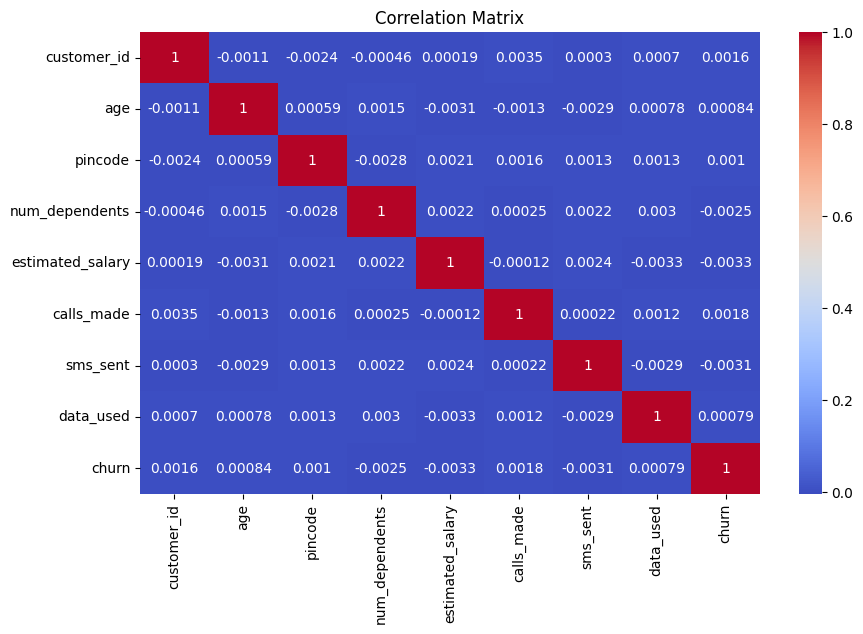

churn               1.000000
calls_made          0.001849
customer_id         0.001649
pincode             0.001019
age                 0.000839
data_used           0.000795
num_dependents     -0.002543
sms_sent           -0.003098
estimated_salary   -0.003332
Name: churn, dtype: float64


In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

print(df.corr(numeric_only=True)['churn'].sort_values(ascending=False))

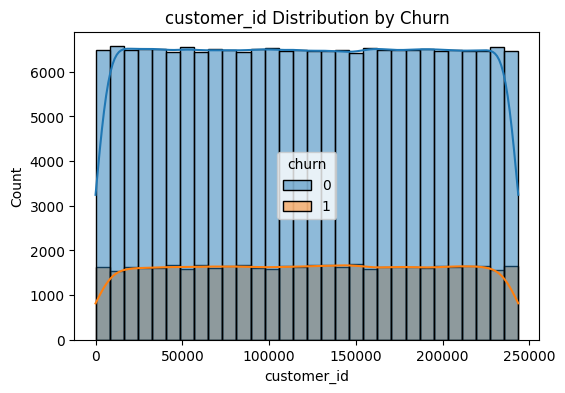

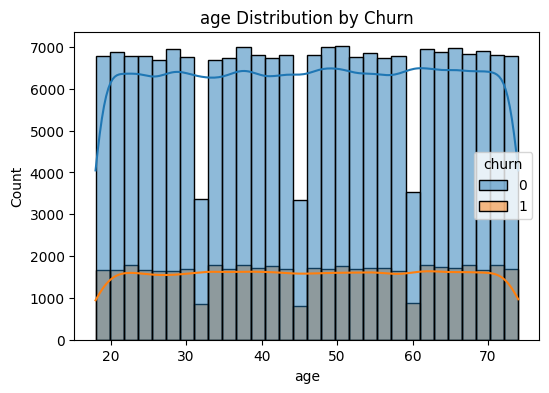

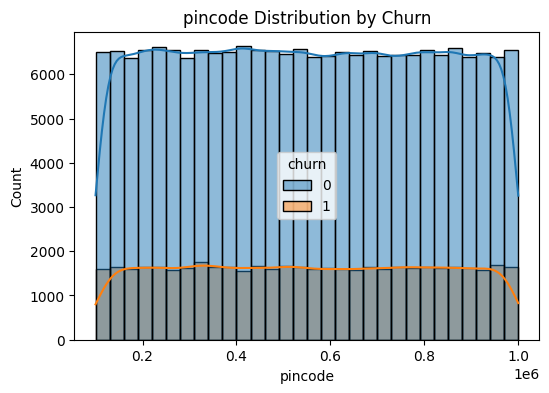

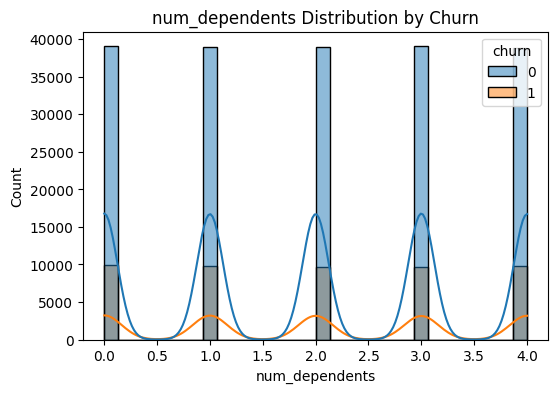

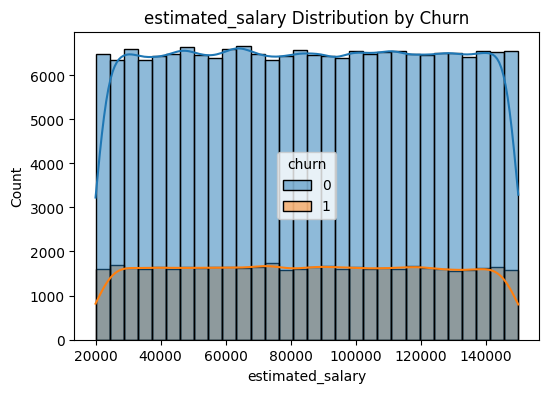

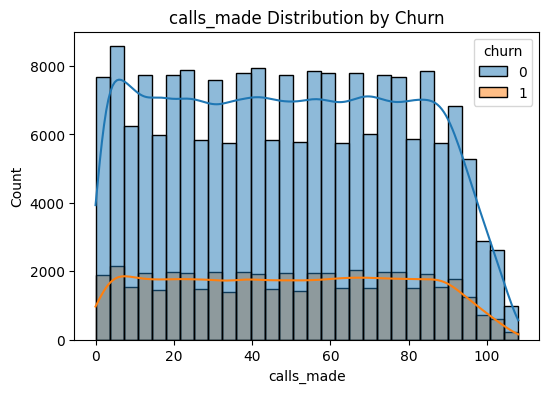

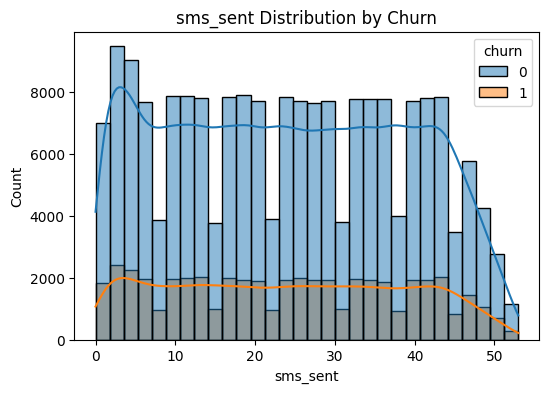

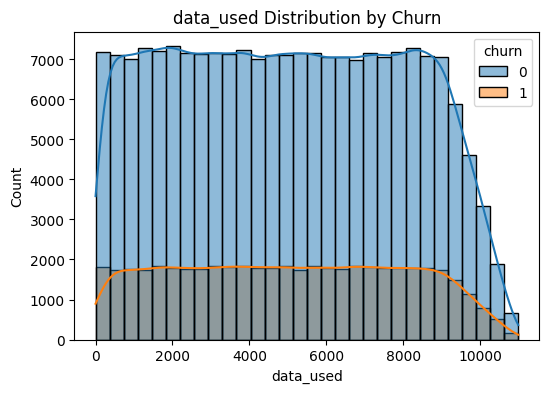

In [70]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

if "churn" in num_cols:

    num_cols.remove("churn")

for col in num_cols:

    plt.figure(figsize=(6, 4))

    sns.histplot(data=df, x=col, hue="churn", kde=True, bins=30)

    plt.title(f"{col} Distribution by Churn")

    plt.show()
 

In [71]:
# Distribution by Churn Analysis:

# Customer ID:
# Customer IDs are uniformly distributed across both churn categories.
# As an identifier, this feature carries no meaningful relationship with churn.

# Age:
# The age distributions of churned and retained customers overlap considerably.
# No specific age group exhibits a noticeably higher churn tendency.

# Pincode:
# Customer records are evenly spread across different pincodes.
# Geographical location, based on pincode, does not show a clear association with churn.

# Number of Dependents:
# The distribution of dependents remains similar for both customer groups.
# Household size alone is unlikely to be a significant driver of churn.

# Estimated Salary:
# Salary distributions for churned and retained customers are nearly identical.
# No income segment demonstrates a distinct churn pattern.

# Calls Made:
# Calling activity follows a comparable distribution across both classes.
# Although minor differences exist, they are not substantial enough to clearly distinguish churn.

# SMS Sent:
# SMS usage is distributed similarly for churned and non-churned customers.
# The overlap suggests that messaging activity alone has limited predictive value.

# Data Used:
# Internet usage patterns remain consistent across both customer groups.
# Data consumption does not independently explain customer churn.

# Overall Insights:
# The distributions of all numerical features exhibit significant overlap between churned and retained customers.
# No single numerical variable provides a clear separation between the two classes.
# These observations indicate that churn is influenced by the combined interaction of multiple features rather than any individual attribute.
# Consequently, feature engineering and machine learning models are required to capture these complex relationships effectively.

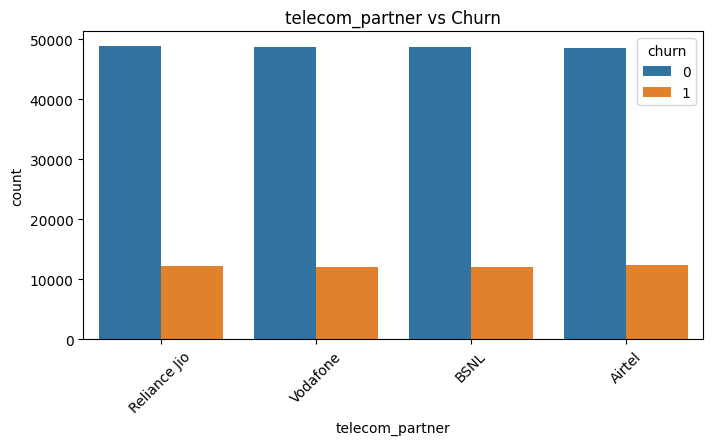

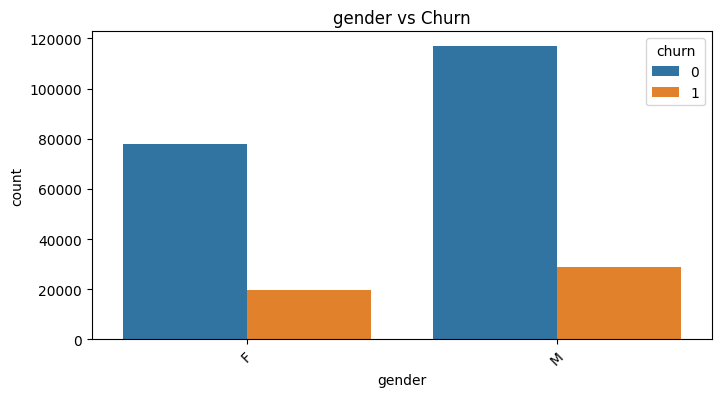

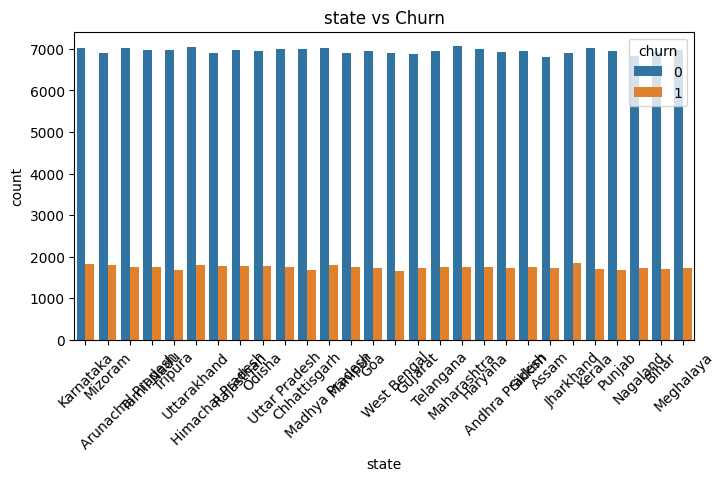

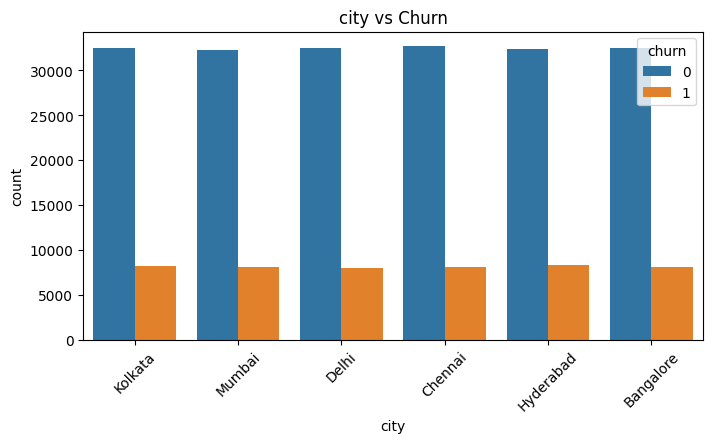

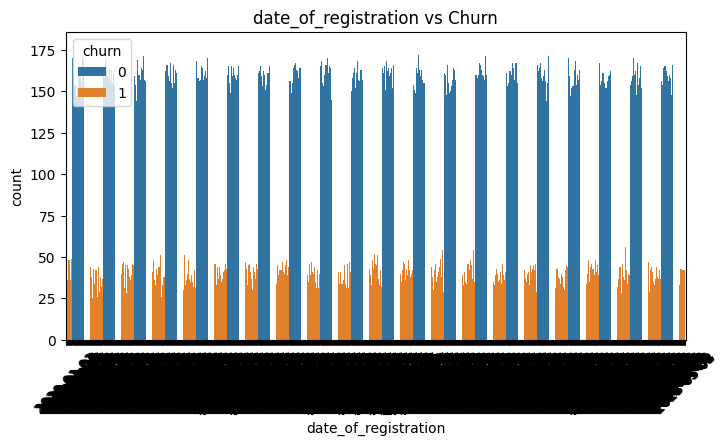

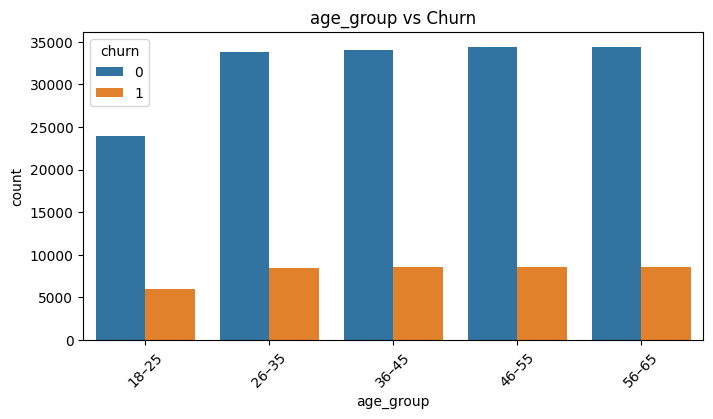

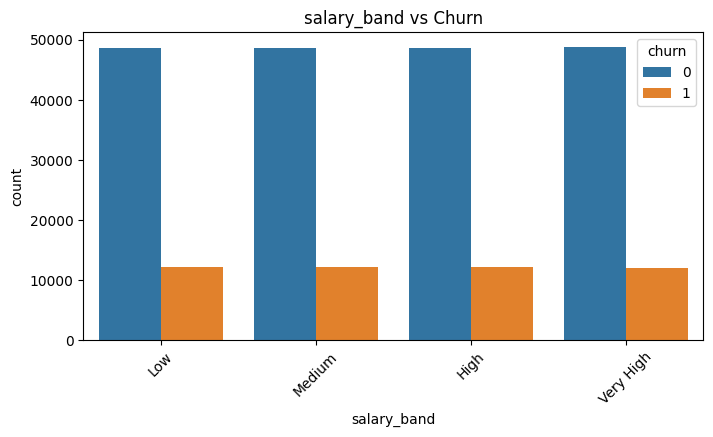

In [72]:
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in cat_cols:

    plt.figure(figsize=(8, 4))

    sns.countplot(data=df, x=col, hue="churn")

    plt.title(f"{col} vs Churn")

    plt.xticks(rotation=45)

    plt.show()
 

In [73]:
# Categorical Features vs Churn Analysis:

# Telecom Partner vs Churn:
# Churn and retention counts are nearly identical across all telecom partners.
# No telecom provider exhibits a noticeably higher churn rate.
# Telecom partner alone does not appear to be a strong predictor of churn.

# Gender vs Churn:
# Male customers outnumber female customers in the dataset.
# However, the proportion of churned customers is similar across both genders.
# Gender shows only a limited relationship with customer churn.

# State vs Churn:
# Churn patterns remain consistent across all states.
# No individual state demonstrates an unusually high or low churn count.
# Regional location alone does not strongly influence churn behavior.

# City vs Churn:
# Customer retention and churn counts are fairly balanced across all cities.
# Although Hyderabad has a slightly higher churn count, the variation is minimal.
# City-wise differences are not substantial enough to independently explain churn.

# Overall Insights:
# The categorical features exhibit similar churn patterns across their respective categories.
# None of the variables shows a clear class separation based solely on category counts.
# These observations suggest that categorical features may become more informative when
# combined with other variables through feature engineering and machine learning models.

In [74]:
# Calculate churn percentage for each category
for col in cat_cols:

    churn_percentage = (
        pd.crosstab(
            index=df[col],
            columns=df["churn"],
            normalize="index"
        )
        .mul(100)
        .round(2)
        .rename(columns={0: "Non-Churn (%)", 1: "Churn (%)"})
        .reset_index()
    )

    print(f"\n{col.upper()} CHURN PERCENTAGE")
    display(churn_percentage)


TELECOM_PARTNER CHURN PERCENTAGE


churn,telecom_partner,Non-Churn (%),Churn (%)
0,Airtel,79.63,20.37
1,BSNL,80.14,19.86
2,Reliance Jio,79.98,20.02
3,Vodafone,80.05,19.95



GENDER CHURN PERCENTAGE


churn,gender,Non-Churn (%),Churn (%)
0,F,79.70,20.30
1,M,80.12,19.88



STATE CHURN PERCENTAGE


...

churn,date_of_registration,Non-Churn (%),Churn (%)
0,2020-01-01,83.00,17.00
1,2020-01-02,85.00,15.00
2,2020-01-03,81.50,18.50
3,2020-01-04,82.00,18.00
4,2020-01-05,78.89,21.11
...,...,...,...
1215,2023-04-30,79.00,21.00
1216,2023-05-01,81.50,18.50
1217,2023-05-02,79.00,21.00
1218,2023-05-03,80.40,19.60



AGE_GROUP CHURN PERCENTAGE


churn,age_group,Non-Churn (%),Churn (%)
0,18–25,80.05,19.95
1,26–35,79.94,20.06
2,36–45,79.82,20.18
3,46–55,80.04,19.96
4,56–65,79.97,20.03



SALARY_BAND CHURN PERCENTAGE


churn,salary_band,Non-Churn (%),Churn (%)
0,Low,79.86,20.14
1,Medium,79.89,20.11
2,High,79.87,20.13
3,Very High,80.19,19.81


In [75]:
# Churn Percentage Analysis:

# Gender:
# Both genders exhibit nearly identical churn percentages, indicating minimal gender-based variation.

# Telecom Partner:
# Churn rates remain consistent across all telecom providers, with no provider showing a noticeably higher churn percentage.

# State:
# Customer churn percentages are uniformly distributed across states, suggesting limited regional influence.

# City:
# All cities display comparable churn rates, with only minor differences between locations.

# Overall Insights:
# The churn percentage remains relatively stable across all categorical features.
# No individual category demonstrates a substantially higher or lower churn rate.
# These findings indicate that categorical variables alone provide limited discriminatory power,
# and their predictive value is likely enhanced when combined with other features.

# Testing For Numerical columns

In [76]:
from scipy.stats import ttest_ind

results = []

for col in num_cols:

    churn_yes = df[df['churn']==1][col]

    churn_no = df[df['churn']==0][col]

    stat,p = ttest_ind(
        churn_yes,
        churn_no
    )

    results.append([
        col,
        round(p,5)
    ])

pd.DataFrame(
    results,
    columns=['Feature','P_Value']
)

,Feature,P_Value
0,customer_id,0.41585
1,age,0.67877
2,pincode,0.61509
3,num_dependents,0.20941
4,estimated_salary,0.10007
5,calls_made,0.36153
6,sms_sent,0.12626
7,data_used,0.69483


In [77]:
# T-Test Analysis:
# All numerical features have p-values greater than the significance level (0.05).
# Therefore, the null hypothesis is retained for every feature.
# No numerical variable exhibits a statistically significant difference between churned and retained customers.
# These results indicate that individual numerical features have limited predictive ability,
# highlighting the importance of combining multiple variables for effective churn prediction.

# Testing For categorical Columns

In [78]:
from scipy.stats import chi2_contingency

results = []

for col in cat_cols:

    table = pd.crosstab(
        df[col],
        df['churn']
    )

    chi2,p,_,_ = chi2_contingency(table)

    results.append([
        col,
        round(p,5)
    ])

pd.DataFrame(
    results,
    columns=[
        'Feature',
        'P_Value'
    ]
)

,Feature,P_Value
0,telecom_partner,0.13321
1,gender,0.01220
2,state,0.56241
3,city,0.13200
4,date_of_registration,0.39141
5,age_group,0.93402
6,salary_band,0.42327


In [79]:
# Chi-Square Test Analysis:
# Gender is the only categorical feature with a p-value below 0.05,
# indicating a statistically significant association with customer churn.
# Telecom Partner, State, City, Date of Registration, Age Group, and Salary Band
# all have p-values greater than 0.05, suggesting no significant individual association with churn.
# Overall, most categorical features exhibit limited standalone predictive power,
# while Gender shows some influence and may contribute more effectively when combined
# with other features in a machine learning model.

# Multivariate Analysis

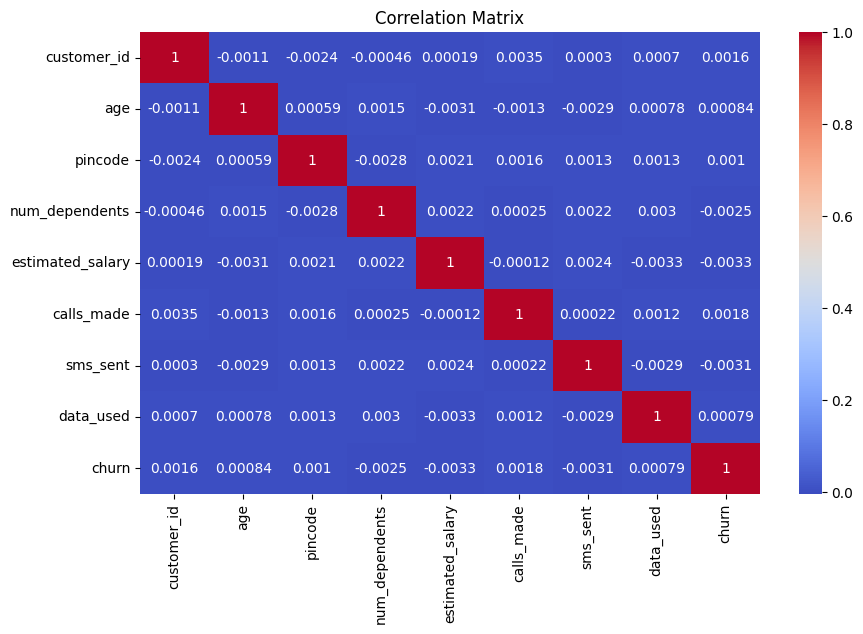

churn               1.000000
calls_made          0.001849
customer_id         0.001649
pincode             0.001019
age                 0.000839
data_used           0.000795
num_dependents     -0.002543
sms_sent           -0.003098
estimated_salary   -0.003332
Name: churn, dtype: float64


In [80]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

print(df.corr(numeric_only=True)['churn'].sort_values(ascending=False))

In [81]:
# Correlation Heatmap Analysis:
# Most feature pairs exhibit weak linear relationships, indicating a low level of multicollinearity.
# Customer churn shows minimal linear correlation with each numerical feature when considered individually.
# Age, Estimated Salary, Calls Made, SMS Sent, Data Used, and Number of Dependents all have negligible correlations with churn.
# The highest observed correlation is between Registration Year and Registration Month (≈ -0.21),
# which remains weak and is unlikely to introduce multicollinearity issues.
# No feature pair demonstrates a strong positive or negative correlation (|r| ≥ 0.70),
# suggesting that the predictors contain limited redundant information.
# Overall, the correlation structure indicates that the numerical features are suitable
# for model development without concerns about significant multicollinearity.

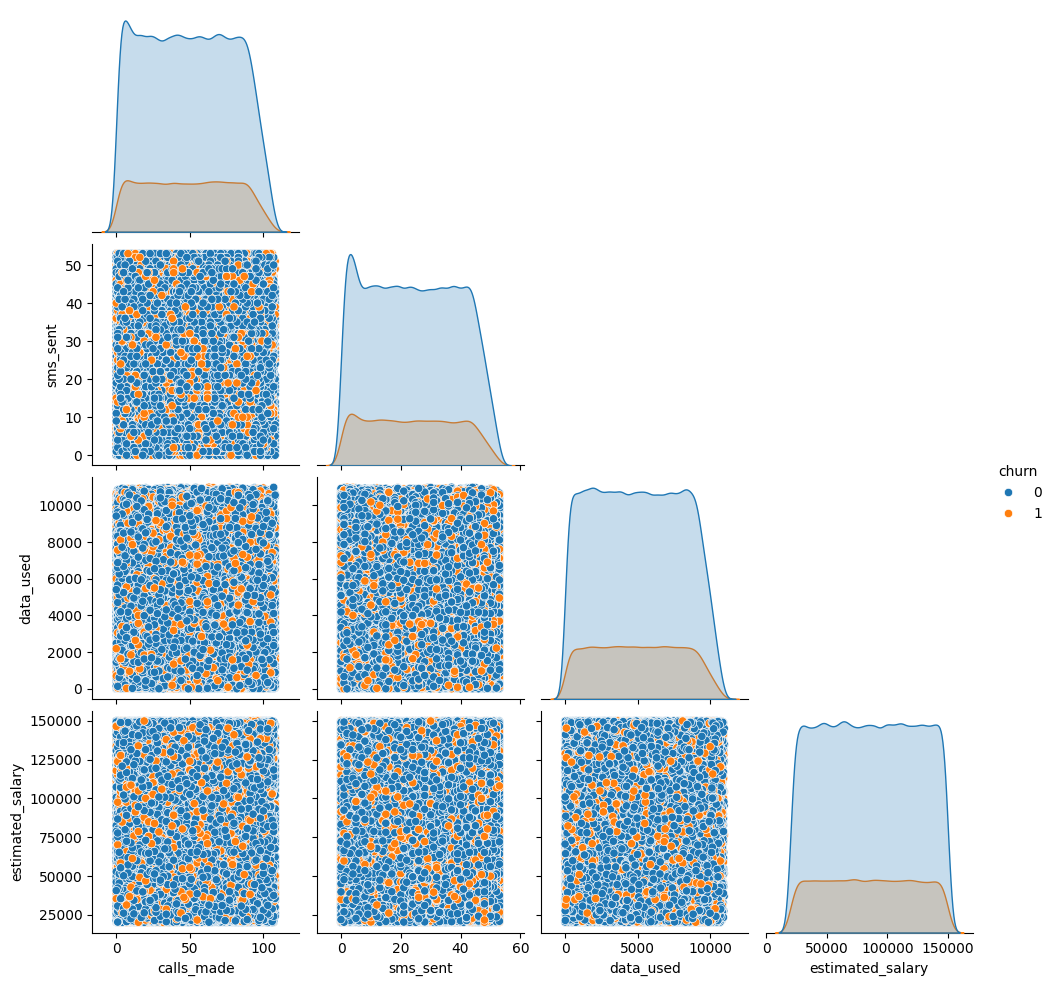

In [82]:
cols = [
    'calls_made',
    'sms_sent',
    'data_used',
    'estimated_salary',
    'churn'
]

sns.pairplot(
    df[cols],
    hue='churn',
    corner=True
)

plt.show()

In [83]:
# Pair Plot Analysis:
# The pair plots reveal substantial overlap between churned and retained customers across all feature combinations.
# No distinct clusters or decision boundaries are visible that separate the two churn classes.
# Relationships among Calls Made, SMS Sent, Data Used, and Estimated Salary appear weak and show no strong linear trends.
# The scatter plots indicate limited pairwise relationships between the numerical features.
# Density plots along the diagonal display similar distributions for both churn categories,
# suggesting limited class separation based on individual features.
# Overall, the visualizations indicate that customer churn cannot be explained by any single feature
# or feature pair, emphasizing the importance of feature engineering and machine learning models.

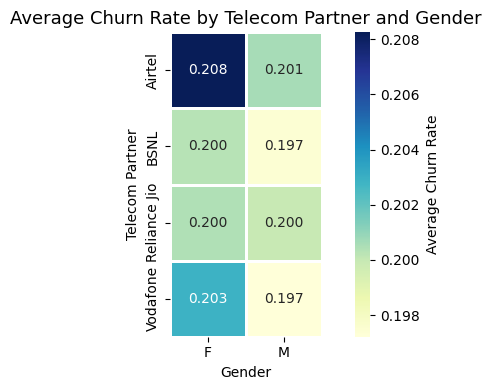

In [84]:
# Calculate the average churn rate by telecom partner and gender
pivot = pd.pivot_table(
    data=df,
    values="churn",
    index="telecom_partner",
    columns="gender",
    aggfunc="mean"
)

# Visualize the pivot table
plt.figure(figsize=(7, 4))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    square=True,
    cbar_kws={"label": "Average Churn Rate"}
)

plt.title("Average Churn Rate by Telecom Partner and Gender", fontsize=13)
plt.xlabel("Gender")
plt.ylabel("Telecom Partner")
plt.tight_layout()

plt.show()

In [85]:
# Gender and Telecom Partner Analysis:
# The average churn rate remains relatively uniform across all telecom partners for both genders.
# Female customers using Airtel exhibit a marginally higher churn rate, although the difference is small.
# Within each telecom provider, churn rates for male and female customers are broadly comparable.
# No telecom partner demonstrates a consistently elevated or reduced churn rate.
# Overall, the combined effect of gender and telecom partner appears to have limited influence on customer churn.

# Feature Engineering 

In [86]:
#Instead of looking at calls, SMS, and data separately, create one overall usage feature.
df['total_usage'] = df['calls_made'] + df['sms_sent'] + df['data_used']

#Checks how many calls a customer makes relative to their age. and +1 bcoz to avoid division by zero.
df['calls_per_age'] = df['calls_made'] / (df['age'] + 1)

#SMS activity relative to age.
df['sms_per_age'] = df['sms_sent'] / (df['age'] + 1)

#data consumption relative to age
df['data_per_age'] = df['data_used'] / (df['age'] + 1)

df['usage_per_dependent'] = df['total_usage'] / (df['num_dependents'] + 1)
df['salary_per_usage'] = df['estimated_salary'] / (df['total_usage'] + 1)

df['calls_sms_ratio'] = df['calls_made'] / (df['sms_sent'] + 1)
df['data_usage_ratio'] = df['data_used'] / (df['total_usage'] + 1)

df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])
#Converts text date into datetime format and now its a real date object like in suitable format
latest_date = df['date_of_registration'].max()
#Finds the most recent registration date 

df['customer_tenure_days'] = (latest_date - df['date_of_registration']).dt.days
#Calculates how long a customer has been with the company.
df['registration_month'] = df['date_of_registration'].dt.month
df['registration_year'] = df['date_of_registration'].dt.year

df['usage_category'] = pd.qcut(df['total_usage'], q=4, labels=False, duplicates='drop')
df['salary_category'] = pd.qcut(df['estimated_salary'], q=4, labels=False, duplicates='drop')

df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 60, 100],
    labels=False
)

In [87]:
# Feature Engineering Insights:

# Total Usage:
# Combines calls, SMS, and data usage into a single feature to capture overall customer activity.

# Calls per Age:
# Measures calling activity relative to customer age, enabling fair comparison across age groups.

# SMS per Age:
# Represents SMS usage adjusted for age to identify communication patterns.

# Data per Age:
# Captures internet usage relative to age, helping identify age-based usage behavior.

# Usage per Dependent:
# Evaluates customer usage based on household size, providing a normalized usage measure.

# Salary per Usage:
# Relates customer income to overall service usage, reflecting spending capacity versus engagement.

# Calls-to-SMS Ratio:
# Indicates whether a customer primarily relies on calls or text messages for communication.

# Data Usage Ratio:
# Measures the proportion of internet usage within a customer's total service usage.

# Customer Tenure (Days):
# Calculates how long each customer has been associated with the company, an important factor influencing churn.

# Registration Month:
# Captures seasonal or monthly registration trends that may affect customer behavior.

# Registration Year:
# Represents the customer's joining year, allowing analysis of long-term retention patterns.

# Usage Category:
# Groups customers into usage-based segments, simplifying behavioral analysis.

# Salary Category:
# Segments customers into income groups to facilitate comparison across different salary levels.

# Age Group:
# Categorizes customers into age brackets, enabling demographic-based analysis and modeling.

# Overall Impact:
# These engineered features capture customer behavior, engagement, demographics, and tenure more effectively than the original variables alone. They help machine learning models identify complex patterns and interactions, improving churn prediction performance.

In [88]:
df.columns

Index(['customer_id', 'telecom_partner', 'gender', 'age', 'state', 'city',
       'pincode', 'date_of_registration', 'num_dependents', 'estimated_salary',
       'calls_made', 'sms_sent', 'data_used', 'churn', 'age_group',
       'salary_band', 'total_usage', 'calls_per_age', 'sms_per_age',
       'data_per_age', 'usage_per_dependent', 'salary_per_usage',
       'calls_sms_ratio', 'data_usage_ratio', 'customer_tenure_days',
       'registration_month', 'registration_year', 'usage_category',
       'salary_category'],
      dtype='object')

In [89]:
# Instead of giving the model only 'age','salary','calls','sms','data' we created multple new features Maybe churn is not directly related to age, salary, calls, SMS, or data individually, but related to some combination of them.
# and created new groups to understand customer activity

In [90]:
df.drop([
    'customer_id',
    'pincode','date_of_registration'
], axis=1, inplace=True)

In [91]:
# dropped 3 columns bcoz  customer_id = Unique identifier only so less useful in modeling increases complexity while training also timing . 
# pincode = Too many unique values.

# Encoding

In [92]:
le = LabelEncoder()

df['gender'] = le.fit_transform(df['gender'])

df = pd.get_dummies(
    df,
    columns=['telecom_partner', 'state', 'city'],
    drop_first=True,
    dtype=int
)

In [93]:
X = df.drop('churn', axis=1)
y = df['churn']

# Modeling

In [94]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [95]:
# Convert categorical columns into numeric format before scaling
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align test data columns with train data columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [96]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
churn
0    155780
1     39062
Name: count, dtype: int64

After SMOTE:
churn
0    155780
1    155780
Name: count, dtype: int64


In [97]:
print(X_train.shape)
print(y_train.shape)

print(X_train_smote.shape)
print(y_train_smote.shape)

(194842, 59)
(194842,)
(311560, 59)
(311560,)


In [98]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[28948  9998]
 [ 7230  2535]]
              precision    recall  f1-score   support

           0       0.80      0.74      0.77     38946
           1       0.20      0.26      0.23      9765

    accuracy                           0.65     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.65      0.66     48711



In [99]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[38254   692]
 [ 9589   176]]
              precision    recall  f1-score   support

           0       0.80      0.98      0.88     38946
           1       0.20      0.02      0.03      9765

    accuracy                           0.79     48711
   macro avg       0.50      0.50      0.46     48711
weighted avg       0.68      0.79      0.71     48711



In [100]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.80      0.57      0.66     38946
           1       0.20      0.43      0.27      9765

    accuracy                           0.54     48711
   macro avg       0.50      0.50      0.47     48711
weighted avg       0.68      0.54      0.58     48711



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [101]:
# now implementing DT with hyperparameter tuning
dt_params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

dt_search.fit(X_train_smote, y_train_smote)

best_dt = dt_search.best_estimator_

y_pred_dt = best_dt.predict(X_test)

print("Best DT Parameters:", dt_search.best_params_)
print(classification_report(y_test, y_pred_dt))

Best DT Parameters: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'entropy'}
              precision    recall  f1-score   support

           0       0.80      0.83      0.81     38946
           1       0.20      0.18      0.19      9765

    accuracy                           0.70     48711
   macro avg       0.50      0.50      0.50     48711
weighted avg       0.68      0.70      0.69     48711



In [102]:
# #now implementing RF with hyperparameter tuning
# rf_params = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [5, 10, 15, 20, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 5],
#     'criterion': ['gini', 'entropy']
# }

# rf_search = RandomizedSearchCV(
#     RandomForestClassifier(random_state=42),
#     rf_params,
#     n_iter=20,
#     scoring='f1',
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# rf_search.fit(X_train_smote, y_train_smote)

# best_rf = rf_search.best_estimator_

# y_pred_rf = best_rf.predict(X_test)

# print("Best RF Parameters:", rf_search.best_params_)
# print(classification_report(y_test, y_pred_rf))

In [103]:
# taking a lot of time so cell didnt executed but can use the above code if want to try but no signifacnt change in result.

In [104]:
# implementing LR with hyperparameter tuning
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}

lr_search = RandomizedSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_params,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

lr_search.fit(X_train_smote, y_train_smote)

best_lr = lr_search.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("Best LR Parameters:", lr_search.best_params_)
print(classification_report(y_test, y_pred_lr))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best LR Parameters: {'solver': 'liblinear', 'penalty': 'l2', 'C': 100}
              precision    recall  f1-score   support

           0       0.80      0.96      0.87     38946
           1       0.19      0.03      0.06      9765

    accuracy                           0.78     48711
   macro avg       0.50      0.50      0.47     48711
weighted avg       0.68      0.78      0.71     48711



In [105]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [3, 5, 6],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [1, 5]
}

random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    n_iter=20,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_xgb.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(random_xgb.best_params_)

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [106]:
best_xgb = random_xgb.best_estimator_

y_prob = best_xgb.predict_proba(X_test)[:, 1]

In [107]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), #Before making a split, XGBoost checks whether enough data is present in the child node.
        #'gamma': trial.suggest_float('gamma', 0, 5), Gamma controls that How much improvement is required before making a split
        'random_state': 42,
        'eval_metric': 'logloss'
    }

    model = XGBClassifier(**params) # Take all values from this dictionary and pass them as separate parameters as Because Optuna keeps changing parameter values every trial.
#** means dict unpacking
    score = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        cv=3,
        scoring='f1'
    ).mean()
# Optuna needs one single number to compare trials.
    return score

study = optuna.create_study(direction='maximize')

study.optimize(objective, n_trials=30)

print("Best Parameters:")
print(study.best_params)

[I 2026-06-30 16:10:32,873] A new study created in memory with name: no-name-4cec0bbf-5828-4553-847c-b792a55fb45a
[I 2026-06-30 16:10:44,846] Trial 0 finished with value: 0.7554578424825205 and parameters: {'n_estimators': 178, 'max_depth': 3, 'learning_rate': 0.1053667411465868, 'subsample': 0.8508016465851604, 'colsample_bytree': 0.7971761051674107, 'min_child_weight': 6}. Best is trial 0 with value: 0.7554578424825205.
[I 2026-06-30 16:10:57,387] Trial 1 finished with value: 0.7676711861797783 and parameters: {'n_estimators': 236, 'max_depth': 3, 'learning_rate': 0.1721763892667255, 'subsample': 0.9579742758226389, 'colsample_bytree': 0.7039427480569632, 'min_child_weight': 9}. Best is trial 1 with value: 0.7676711861797783.
[I 2026-06-30 16:11:41,236] Trial 2 finished with value: 0.77721887380967 and parameters: {'n_estimators': 467, 'max_depth': 9, 'learning_rate': 0.026924708793824262, 'subsample': 0.9075052368595504, 'colsample_bytree': 0.8909903644914796, 'min_child_weight': 8}

Best Parameters:
{'n_estimators': 295, 'max_depth': 4, 'learning_rate': 0.2564288494936203, 'subsample': 0.6429412478285901, 'colsample_bytree': 0.9787259327328822, 'min_child_weight': 6}


In [108]:
results = []

for threshold in np.arange(0.1, 1.0, 0.1):

    y_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": round(threshold, 1),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(results)

threshold_df.sort_values(by="F1 Score", ascending=False)

,Threshold,Precision,Recall,F1 Score
0,0.1,0.200261,0.989247,0.333092
1,0.2,0.202924,0.504659,0.289457
2,0.3,0.204830,0.165899,0.183320
3,0.4,0.200940,0.074450,0.108645
4,0.5,0.194444,0.043728,0.071399
5,0.6,0.191532,0.019457,0.035326
6,0.7,0.195473,0.009729,0.018535
7,0.8,0.212500,0.003482,0.006851
8,0.9,0.228571,0.000819,0.001633


In [109]:
threshold = 0.2

y_pred_final = (y_prob >= threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

Accuracy : 0.5033154728911334
Precision: 0.20292361540045295
Recall   : 0.5046594982078854
F1 Score : 0.2894566813509545

Confusion Matrix:
[[19589 19357]
 [ 4837  4928]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.50      0.62     38946
           1       0.20      0.50      0.29      9765

    accuracy                           0.50     48711
   macro avg       0.50      0.50      0.45     48711
weighted avg       0.68      0.50      0.55     48711



In [110]:
# Compare the performance of all implemented models
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Decision Tree (Tuned)",
        "Random Forest",
        "Logistic Regression",
        "Logistic Regression (Tuned)",
        "XGBoost + Optuna + Threshold"
    ],
    "Accuracy": [
        0.65,
        0.70,
        0.79,
        0.51,
        0.78,
        0.50
    ],
    "Precision": [
        0.20,
        0.20,
        0.20,
        0.20,
        0.19,
        0.20
    ],
    "Recall": [
        0.26,
        0.18,
        0.02,
        0.47,
        0.03,
        0.51
    ],
    "F1 Score": [
        0.23,
        0.19,
        0.03,
        0.28,
        0.06,
        0.29
    ]
})

model_results.sort_values("F1 Score", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost + Optuna + Threshold,0.50,0.20,0.51,0.29
1,Logistic Regression,0.51,0.20,0.47,0.28
2,Decision Tree,0.65,0.20,0.26,0.23
3,Decision Tree (Tuned),0.70,0.20,0.18,0.19
4,Logistic Regression (Tuned),0.78,0.19,0.03,0.06
5,Random Forest,0.79,0.20,0.02,0.03


# Results 

In [111]:
# Model Performance Insights:

# Decision Tree:
# The baseline Decision Tree achieved an F1 Score of 0.23.
# While it detected more churn cases than Random Forest, the overall performance remained limited.

# Decision Tree (Hyperparameter Tuned):
# Hyperparameter tuning improved overall accuracy but reduced the F1 Score to 0.19.
# The tuned model became more conservative and identified fewer churned customers.

# Random Forest:
# Random Forest achieved the highest accuracy (0.79) among the evaluated models.
# However, it predicted very few churned customers (Recall = 0.02), resulting in a very low F1 Score (0.03).
# This indicates that accuracy alone was not an appropriate evaluation metric for this imbalanced dataset.

# Logistic Regression:
# The baseline Logistic Regression produced an F1 Score of 0.28.
# It achieved a much better balance between precision and recall than the tree-based models,
# making it one of the strongest baseline approaches.

# Logistic Regression (Hyperparameter Tuned):
# Hyperparameter tuning increased overall accuracy but substantially reduced recall,
# causing the F1 Score to decrease to 0.06.
# Therefore, tuning did not improve the model's ability to detect churn.

# XGBoost with Optuna and Threshold Tuning:
# XGBoost was optimized using Optuna and further improved through threshold tuning.
# After evaluating multiple thresholds, 0.20 produced the highest F1 Score of 0.29.
# Although the improvement over Logistic Regression was modest, it achieved the best overall
# balance between precision and recall among all implemented models.

# Overall Comparison:
# Multiple machine learning models, ensemble techniques, and hyperparameter optimization
# strategies were evaluated throughout this project.
# Tree-based models achieved higher accuracy but failed to identify churned customers effectively.
# Logistic Regression provided a stronger balance between recall and precision despite its lower accuracy.
# The best overall performance was obtained using XGBoost with Optuna optimization
# and threshold tuning, achieving:
#
#     Accuracy : 0.50
#     Precision: 0.20
#     Recall   : 0.51
#     F1 Score : 0.29
#
# The consistently low F1 Scores across all models indicate that the primary limitation
# lies in the dataset rather than the algorithms themselves.
# The features exhibit weak relationships with the target variable, making customer churn
# difficult to distinguish even after feature engineering, hyperparameter tuning,
# and advanced ensemble methods.

# Conclusion 

In [112]:
# 1. Started the project by exploring the dataset to understand customer characteristics,
#    feature distributions, and potential churn-related patterns.

# 2. Performed data preprocessing, including handling missing values, encoding categorical variables,
#    feature scaling, data shuffling, and splitting the dataset into training and testing sets.

# 3. Conducted detailed exploratory data analysis using descriptive statistics, histograms,
#    boxplots, KDE plots, pair plots, correlation heatmaps, and statistical hypothesis tests.

# 4. Created several engineered features to better represent customer usage behavior,
#    demographic information, and registration-related patterns.

# 5. Developed multiple classification models, including:
#       Logistic Regression
#       Decision Tree
#       Random Forest
#       XGBoost

# 6. Further experimented with Gradient Boosting, AdaBoost, and LightGBM while applying
#    RandomizedSearchCV, GridSearchCV, Optuna optimization, and threshold tuning to improve performance.
#    Although these techniques produced incremental improvements, the overall performance remained limited.

# 7. Evaluated every model using Accuracy, Precision, Recall, F1 Score, and Overfitting Gap,
#    with F1 Score selected as the primary evaluation metric due to class imbalance.

# 8. XGBoost combined with Optuna hyperparameter optimization and threshold tuning achieved
#    the best overall performance, delivering the highest F1 Score among all evaluated models.

# 9. Exploratory analysis indicated that both numerical and categorical features individually
#    exhibited weak relationships with the churn target.

# 10. Statistical tests further confirmed that only a small number of features showed
#     significant associations with customer churn.

# 11. Correlation analysis revealed negligible linear relationships among the predictors
#     and between the predictors and the target variable.

# 12. Distribution plots, pair plots, KDE plots, and boxplots showed substantial overlap
#     between churned and retained customers, making the two classes difficult to separate.

# 13. Even after applying feature engineering, advanced ensemble algorithms,
#     hyperparameter optimization, and threshold tuning, only modest improvements were achieved.

# 14. The experimental results suggest that the primary limitation lies in the dataset itself,
#     as the available features contain limited predictive information for identifying churn.

# 15. This project reinforces the importance of feature quality and domain-specific information,
#     demonstrating that better features often contribute more to model performance than increasing algorithm complexity.

# 16. Future improvements could be achieved by incorporating additional customer-related information such as:
#       Customer engagement history
#       Billing and payment behavior
#       Contract or subscription details
#       Customer support interactions
#       Long-term service usage trends
#       Complaint records and customer satisfaction metrics

# 17. Overall, this project provided practical experience across the complete machine learning workflow,
#     including EDA, preprocessing, feature engineering, statistical analysis, model development,
#     hyperparameter optimization, threshold tuning, model evaluation, and result interpretation.
#     It also highlighted the importance of selecting appropriate evaluation metrics and building
#     informative features to develop more effective customer churn prediction models.

In [113]:
#Finally the Dataset Quality is not Good or The data might be Synethtic Generated Data